In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [19]:
import os

In [24]:
data_path = '../Data_Cleaning_and_Preprocessing/Processed_data_for_each_device/'

In [25]:
files = os.listdir(data_path)

In [26]:
appliances = sorted({f[7:-4] for f in files if f.startswith("x_test")})

In [27]:
print(f"Types of Devices: {appliances}")

Types of Devices: ['Air Conditioning', 'Computer', 'Dishwasher', 'Fridge', 'Heater', 'Lights', 'Microwave', 'Oven', 'TV', 'Washing Machine']


In [31]:
demotrainx = pd.read_csv(f"{data_path}x_train_{"TV"}.csv")
demotrainy = pd.read_csv(f"{data_path}y_train_{"TV"}.csv")

In [32]:
print(type(demotrainx))
print(type(demotrainy))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [33]:
demotrainx.shape

(8419, 9)

In [34]:
demotrainy.shape

(8419, 1)

Training Linear Regression for: Air Conditioning
MAE : 0.6830
RMSE : 0.7999


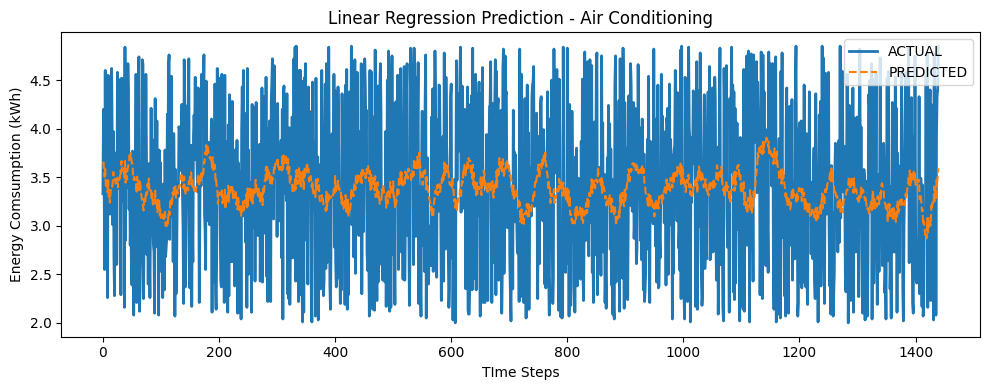

Training Linear Regression for: Computer
MAE : 0.4363
RMSE : 0.5037


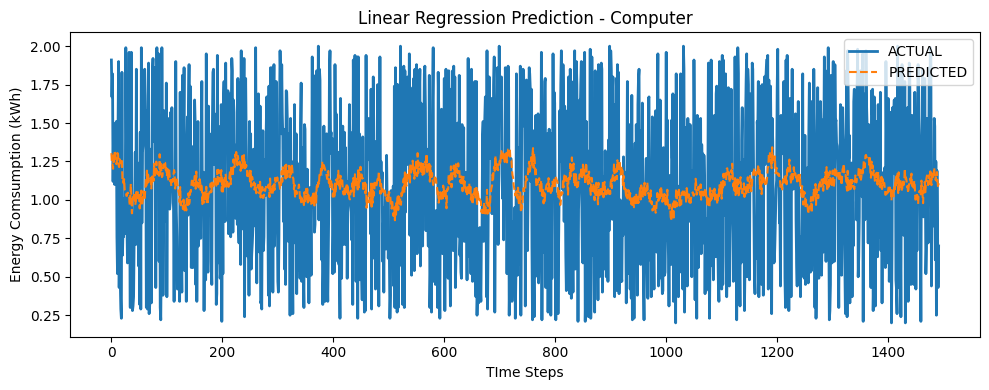

Training Linear Regression for: Dishwasher
MAE : 0.4414
RMSE : 0.5137


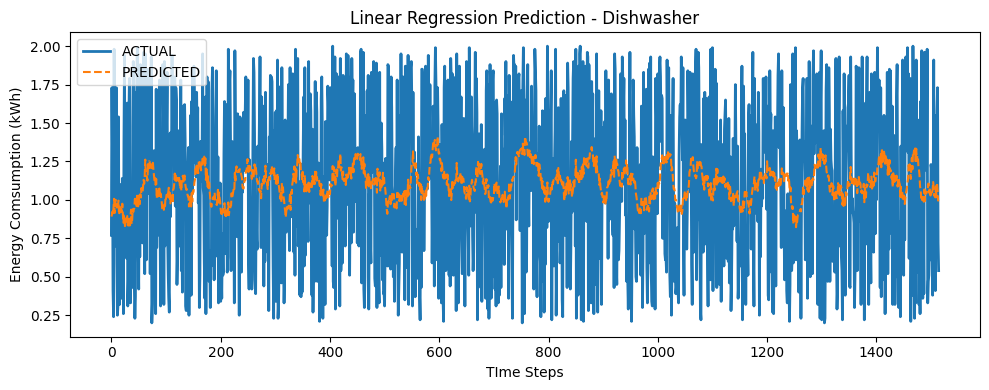

Training Linear Regression for: Fridge
MAE : 0.0985
RMSE : 0.1137


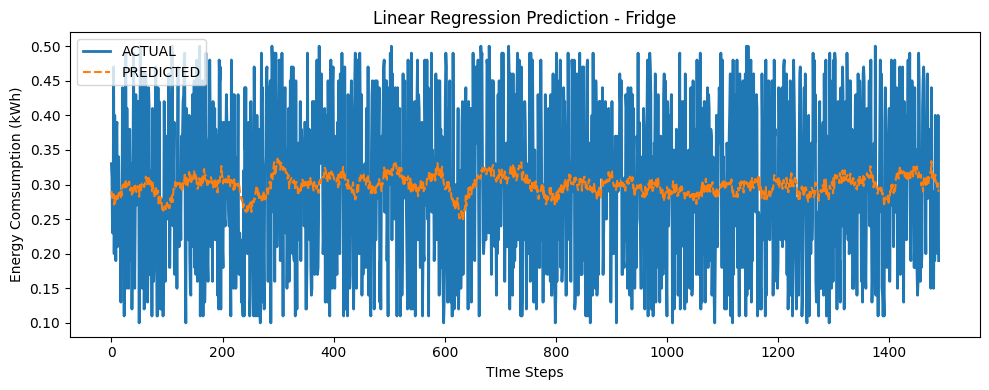

Training Linear Regression for: Heater
MAE : 0.6955
RMSE : 0.8049


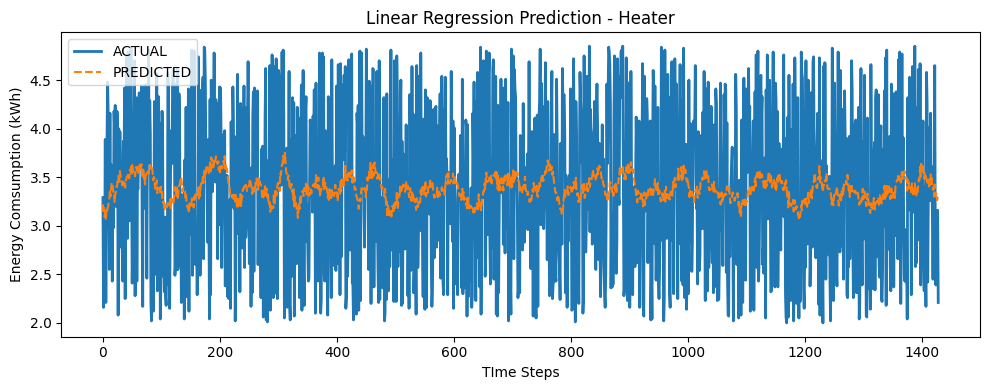

Training Linear Regression for: Lights
MAE : 0.4289
RMSE : 0.4995


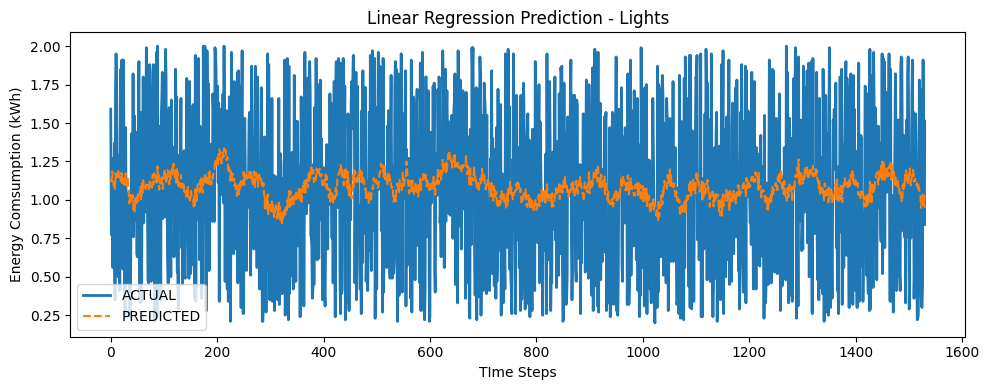

Training Linear Regression for: Microwave
MAE : 0.4331
RMSE : 0.5031


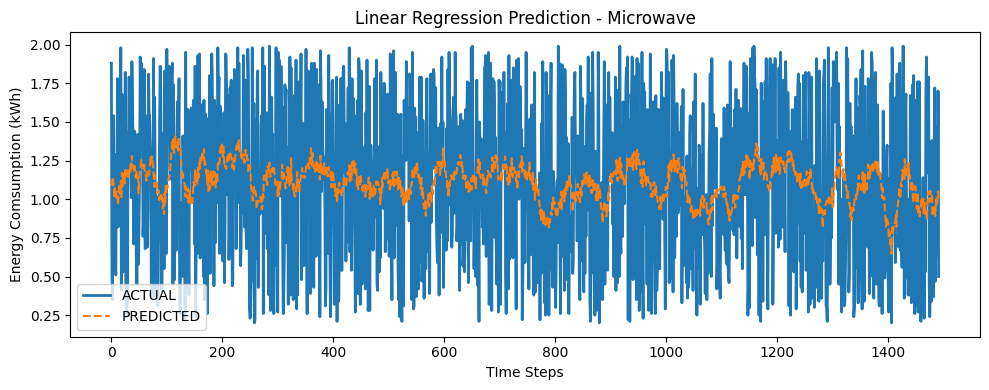

Training Linear Regression for: Oven
MAE : 0.4384
RMSE : 0.5100


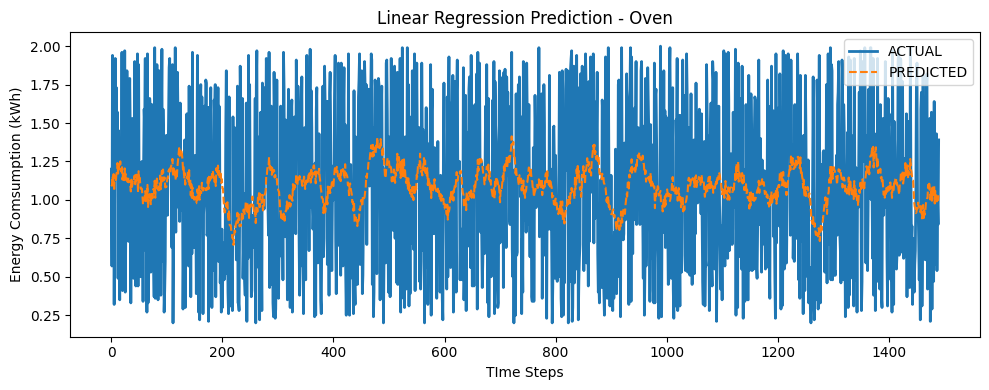

Training Linear Regression for: TV
MAE : 0.4382
RMSE : 0.5078


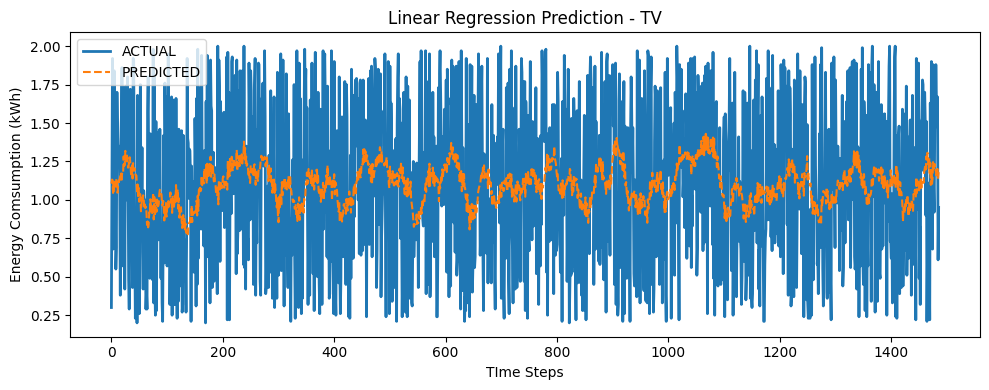

Training Linear Regression for: Washing Machine
MAE : 0.4406
RMSE : 0.5091


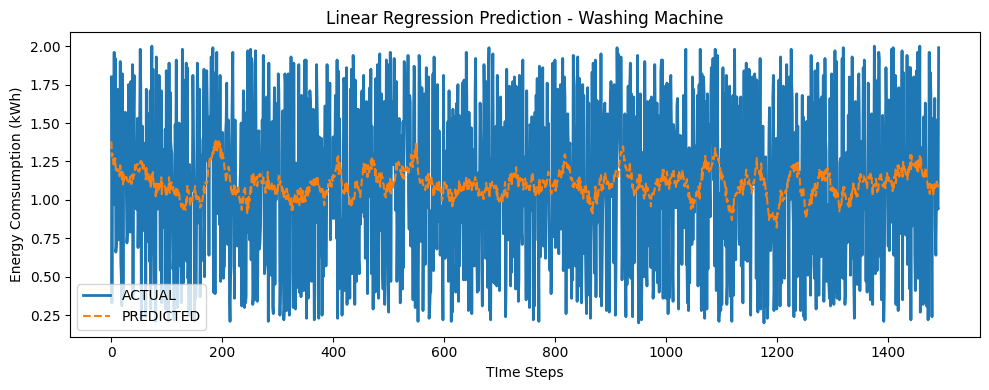

,Appliance,MAE,RMSE
0,Air Conditioning,0.683017,0.799908
1,Computer,0.436321,0.503666
2,Dishwasher,0.441374,0.513663
3,Fridge,0.098517,0.113672
4,Heater,0.695515,0.804875
5,Lights,0.428921,0.499550
6,Microwave,0.433094,0.503119
7,Oven,0.438439,0.509963
8,TV,0.438239,0.507798
9,Washing Machine,0.440626,0.509069


In [39]:
results = []
for appliance in appliances:
    print(f"Training Linear Regression for: {appliance}")
    x_train = pd.read_csv(f"{data_path}x_train_{appliance}.csv")
    x_test = pd.read_csv(f"{data_path}x_test_{appliance}.csv")
    y_train = pd.read_csv(f"{data_path}y_train_{appliance}.csv").values.ravel()
    y_test = pd.read_csv(f"{data_path}y_test_{appliance}.csv").values.ravel()


    model = LinearRegression()
    model.fit(x_train, y_train)
    
    y_predict = model.predict(x_test)

    mae = mean_absolute_error(y_test, y_predict)
    rmse = np.sqrt(mean_squared_error(y_test, y_predict))
    # mape = (np.mean(np.abs((y_test - y_predict)/y_test))) * 100
    # accuracy = 100-mape
    results.append({
        "Appliance" : appliance,
        "MAE" : mae,
        "RMSE" : rmse,
        # "Accuracy" : accuracy,
    })

    print(f"MAE : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    # print(f"RMSE : {accuracy:.4f}%")

    plt.figure(figsize = (10,4))
    plt.plot(y_test, label ="ACTUAL", linewidth = 2)
    plt.plot(y_predict, label ="PREDICTED", linestyle = "--")
    plt.title(f"Linear Regression Prediction - {appliance}")
    
    plt.xlabel("TIme Steps")
    plt.ylabel("Energy Comsumption (kWh)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    joblib.dump(
        model,
        f"models/linear_regression_{appliance}.pkl"
    )

results_df = pd.DataFrame(results)
results_df